### ***Flight Price Prediction Case Study - Neural Network***

#### ***Context and Problem***
 - *The objective of this project is to predict the price of a flight with a set of relevant flight details provided*
 - *The flight details have information related to flight timings, source and destination details, route details, stops in between, etc.*
 - *The dataset consists of about one year of information about various flights and their respective prices.*
 
#### ***Data Information***

*The data at hand has eleven features about the spending on advertising and the target variable is the net sales. Attributes are:*

- *`Airline` - Company that provides air transport services for traveling passengers. (Independent Variable)*
- *`Date_of_Journey` - Date of Journey*
- *`Source`  - From where the flight is takes off.(Independent Variable)*
- *`Destination` - To where the flight is going.(Independent Variable)*
- *`Route`   - What is the route of each flight.(Independent Variable)*
- *`Dep_Time` - Departure Time of the flight.(Independent Variable)*
- *`Arrival_Time` - Arrival Time of the flight.(Independent Variable)*
- *`Duration` - Total duration of the flight.(Independent Variable)*
- *`Total_Stops` - Number of stops between source and destination.(Independent Variable)*
- *`Additional_info` - Additional information about the flight is given.(Independent Variable)*
- *`Price` - Price of each flight.(Dependent Variable)*

***Key Items Covered***

*- Import Libraries*<br>
*- Dataset Load and Review*<br>
*- Temporal Feature Extraction*<br>
*- Exploratory Data Analysis*<br>
*- Train/Test Split*<br>
*- Normalization - StandardScaler*<br>
*- Categorical Encoding*<br>
*- Model Building - Model 1 - DNN*<br>
*- Model Building - Model 2 - DNN Early Stopping*<br>
*- Model Building - Model 3 - DNN Using Dropout*<br>
*- Model Building - Model 4 - DNN Using Batch Normalization*<br>
*- Model Building - Model 5 - DNN Using Dropout and other changes*<br>

#### ***Import required libraries***

In [1]:
# Data Handling and Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Preprocessing and Splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Evaluation Metrics
from sklearn.metrics import explained_variance_score, mean_squared_error, r2_score, mean_absolute_error

# Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, InputLayer, BatchNormalization
from tensorflow.keras import backend
from tensorflow.keras.optimizers import Adam, RMSprop
from keras import callbacks
from keras.callbacks import ModelCheckpoint
from keras.layers import BatchNormalization

# Miscellaneous
from random import shuffle
import warnings
warnings.filterwarnings("ignore")

#### ***Dataset load and Review***

In [2]:
#Since data is in form of excel file we have to use pandas pd.read_excel to load the data.
data = pd.read_excel('data/46_Data.xlsx')

In [3]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
#Information about the data
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10682 entries, 0 to 10681
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Date_of_Journey  10682 non-null  object
 2   Source           10682 non-null  object
 3   Destination      10682 non-null  object
 4   Route            10681 non-null  object
 5   Dep_Time         10682 non-null  object
 6   Arrival_Time     10682 non-null  object
 7   Duration         10682 non-null  object
 8   Total_Stops      10681 non-null  object
 9   Additional_Info  10682 non-null  object
 10  Price            10682 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.1+ KB


In [5]:
#Checking the shape of the data
data.shape

(10682, 11)

In [6]:
#finding the null values
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [7]:
# Checking where the null value present
data[data['Route'].isna()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9038,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [8]:
#drop the null values
data.dropna(inplace=True)

In [9]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [10]:
#Checking the dtypes of the variables in the data
data.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

#### ***Temporal Feature Extraction***

***With objective of capturing seasonality, cyclical patterns, and time based behaviors***

***Convert Date/Time Data***

- `Date_of_Journey`
- `Dep_Time`
- `Arrival_Time`

In [11]:
# Creating a function to convert those columns into datetime dtype
def To_Datetime(data,column):
    data[column] = pd.to_datetime(data[column])
    return data[column]


To_Datetime(data,'Date_of_Journey')
To_Datetime(data,'Dep_Time')
To_Datetime(data,'Arrival_Time')

0       2025-03-22 01:10:00
1       2025-09-30 13:15:00
2       2025-06-10 04:25:00
3       2025-09-30 23:30:00
4       2025-09-30 21:35:00
                ...        
10677   2025-09-30 22:25:00
10678   2025-09-30 23:20:00
10679   2025-09-30 11:20:00
10680   2025-09-30 14:10:00
10681   2025-09-30 19:15:00
Name: Arrival_Time, Length: 10681, dtype: datetime64[ns]

In [12]:
# creating new columns
data['Day_of_Journey'] = data['Date_of_Journey'].dt.day
data['Month_of_Journey'] = data['Date_of_Journey'].dt.month

In [13]:
# Extracting hour and minute values from Dep_time variable
data['Dep_hour'] = data['Dep_Time'].dt.hour
data['Dep_minute'] = data['Dep_Time'].dt.minute

# Extracting hour value from Dep_time variable
data['Arrival_hour'] = data['Arrival_Time'].dt.hour
data['Arrival_minute'] = data['Arrival_Time'].dt.minute

In [14]:
# dropping the original columns
data.drop(['Date_of_Journey',
           'Dep_Time',
           'Arrival_Time'],axis=1,inplace=True)

In [15]:
data.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hour,Dep_minute,Arrival_hour,Arrival_minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35


***Convert Duration into Minutes***

In [16]:
duration = list(data['Duration'])

# Normalize all entries to "Xh Ym" format
for i in range(len(duration)):
    if len(duration[i].split(' ')) == 2:
        continue
    elif 'h' in duration[i]:
        duration[i] = duration[i] + ' 0m'
    else:
        duration[i] = '0h ' + duration[i]

# Convert to total minutes
duration_total_mins = []
for entry in duration:
    hours = int(entry.split('h')[0])
    minutes = int(entry.split('m')[0].split()[-1])
    total = hours * 60 + minutes
    duration_total_mins.append(total)

# Add to DataFrame
data['Duration_total_mins'] = duration_total_mins


In [17]:
#Dropping Duration variable as we have extracted both hours and mins from it
data.drop(["Duration"], axis = 1, inplace = True)

In [18]:
data.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day_of_Journey,Month_of_Journey,Dep_hour,Dep_minute,Arrival_hour,Arrival_minute,Duration_total_mins
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,22,20,1,10,170
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,5,50,13,15,445
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2 stops,No info,13882,9,6,9,25,4,25,1140
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1 stop,No info,6218,12,5,18,5,23,30,325
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1 stop,No info,13302,1,3,16,50,21,35,285


In [19]:
data.dtypes

Airline                object
Source                 object
Destination            object
Route                  object
Total_Stops            object
Additional_Info        object
Price                   int64
Day_of_Journey          int32
Month_of_Journey        int32
Dep_hour                int32
Dep_minute              int32
Arrival_hour            int32
Arrival_minute          int32
Duration_total_mins     int64
dtype: object

#### ***Exploratory Data Analysis***

***Univariate Analysis***

***Helper Function***

In [20]:
def cat_analysis_percentage(data, column, figsize=(8, 5)):
    """
    Plots a percentage barplot for a categorical feature.
    Args:
        data (pd.DataFrame): The DataFrame containing the data.
        column (str): The column to plot.
        figsize (tuple): Figure size for the plot.
    """
    plt.figure(figsize=figsize)
    categories = data[column].value_counts().index
    total = len(data)

    ax = sns.countplot(data=data, x=column, order=categories, palette='Set2')
    ax.set_title(f'Percentage per {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Percentage')
    ax.tick_params(axis='x', rotation=90)

    for p in ax.patches:
        percent = 100 * p.get_height() / total
        ax.annotate(f'{percent:.1f}%', 
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=10, color='blue')

    plt.tight_layout()
    plt.show()


`Airline`

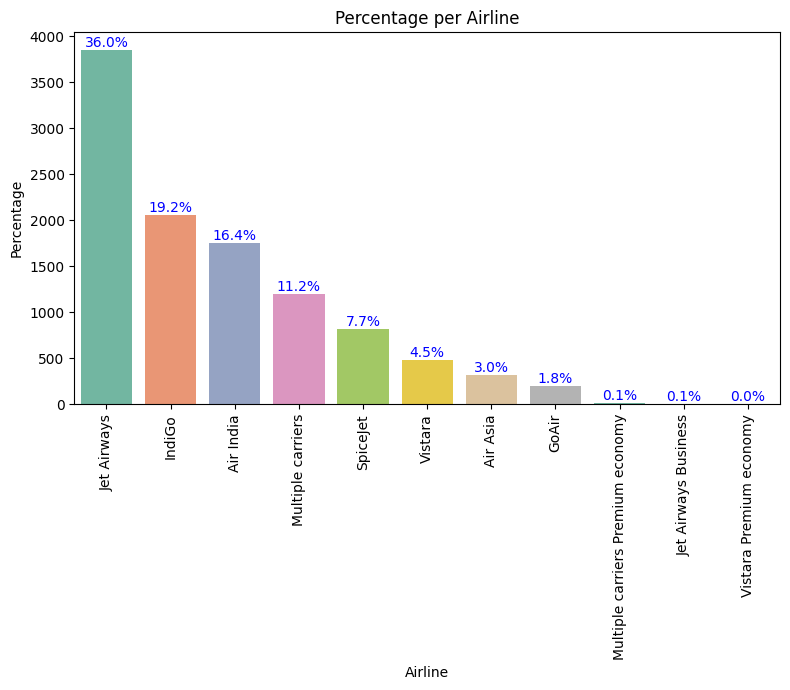

In [21]:
cat_analysis_percentage(data, "Airline", figsize=(8, 7))

***Almost 36% prefer Jet Airways***

`Total Stops`

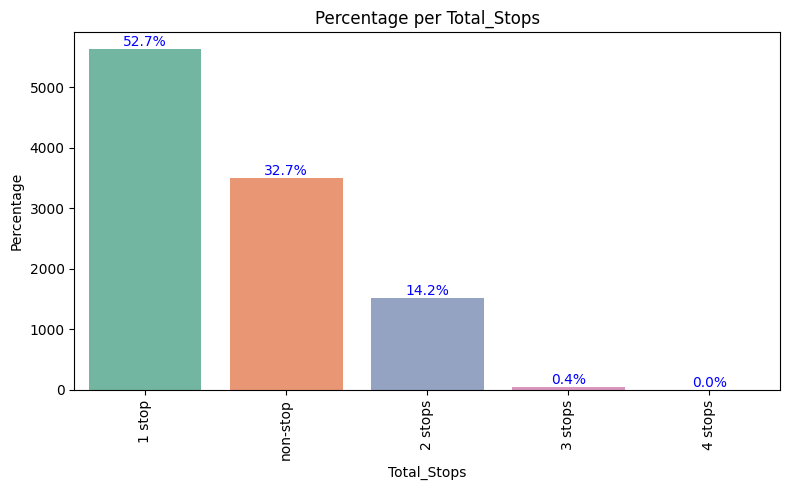

In [22]:
cat_analysis_percentage(data, "Total_Stops", figsize=(8, 5))

***53% of flights are 1 stop, 33% are non stop***

`Source`

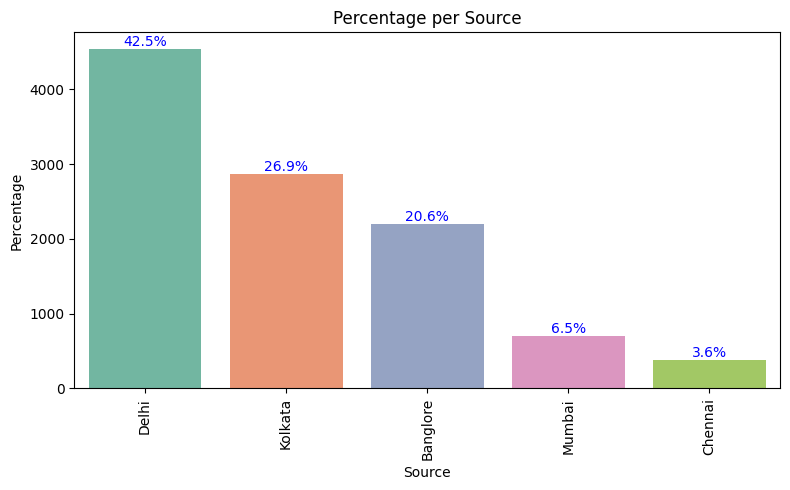

In [23]:
cat_analysis_percentage(data, "Source", figsize=(8, 5))

***43% of flights originate from Delhi, followed by 27% from Kolkata***

`Destination`

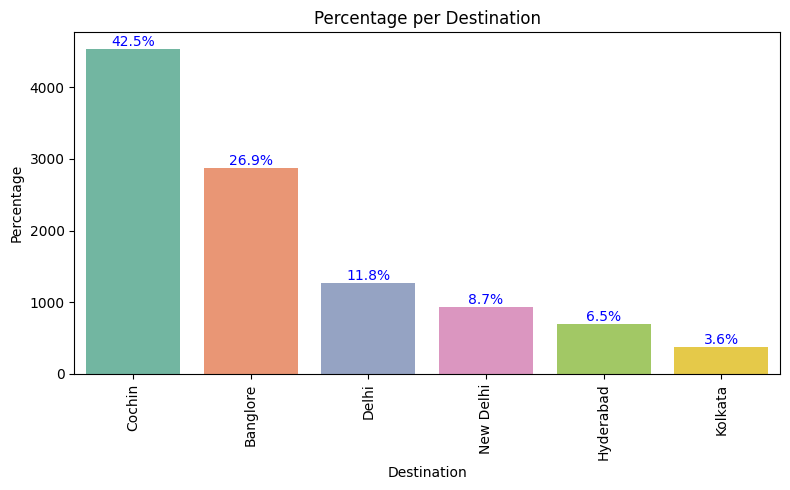

In [24]:
cat_analysis_percentage(data, "Destination", figsize=(8, 5))

In [25]:
#New Delhi and Delhi can be the same so we will merge them
data['Destination'].replace('New Delhi','Delhi',inplace=True)

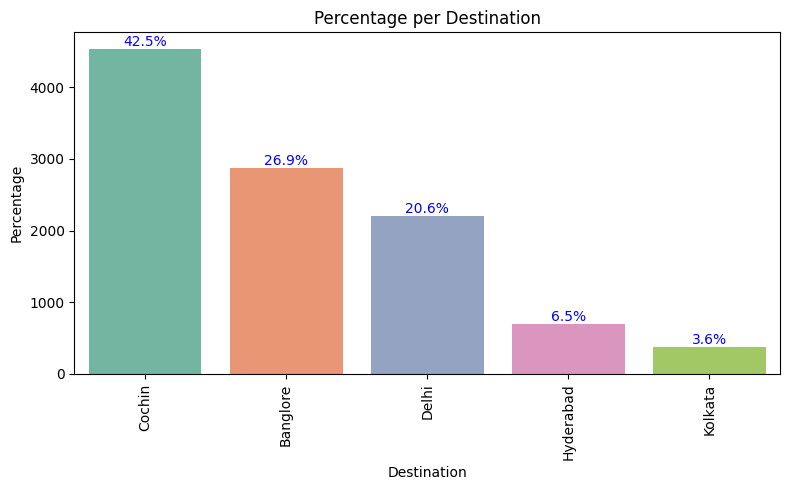

In [26]:
cat_analysis_percentage(data, "Destination", figsize=(8, 5))

***Top Destination is Cochin, followed by Bangalore***

`Additional_Info`

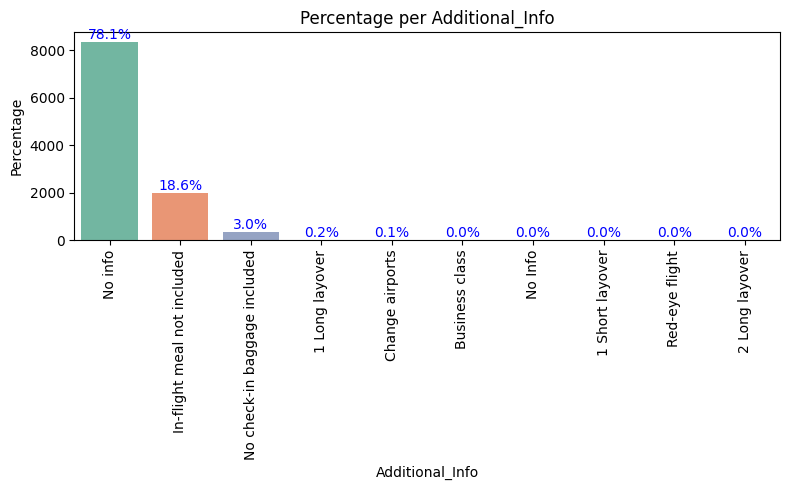

In [27]:
cat_analysis_percentage(data, "Additional_Info", figsize=(8, 5))

***Nothing is given as Additional info in 78% of cases, 19% complained about in-flight meals not being included***

In [28]:
data['Route'].value_counts()

Route
DEL → BOM → COK          2376
BLR → DEL                1552
CCU → BOM → BLR           979
CCU → BLR                 724
BOM → HYD                 621
                         ... 
CCU → RPR → HYD → BLR       1
CCU → VTZ → BLR             1
CCU → IXZ → MAA → BLR       1
BOM → COK → MAA → HYD       1
BOM → BBI → HYD             1
Name: count, Length: 127, dtype: int64

In [29]:
# As most of the Additional_Info (80%) variable contains No_info so we can drop this from the data
# Also Route and Total_Stops are related to each other so we can drop Route variable also

data.drop(["Route", "Additional_Info"], axis = 1, inplace = True)

In [30]:
data.head()

,Airline,Source,Destination,Total_Stops,Price,Day_of_Journey,Month_of_Journey,Dep_hour,Dep_minute,Arrival_hour,Arrival_minute,Duration_total_mins
0,IndiGo,Banglore,Delhi,non-stop,3897,24,3,22,20,1,10,170
1,Air India,Kolkata,Banglore,2 stops,7662,1,5,5,50,13,15,445
2,Jet Airways,Delhi,Cochin,2 stops,13882,9,6,9,25,4,25,1140
3,IndiGo,Kolkata,Banglore,1 stop,6218,12,5,18,5,23,30,325
4,IndiGo,Banglore,Delhi,1 stop,13302,1,3,16,50,21,35,285


In [31]:
# As this is case of Ordinal Categorical type we perform LabelEncoder
# Here Values are assigned with corresponding keys

data['Total_Stops'].replace({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
}, inplace=True)


***Bivariate analysis***

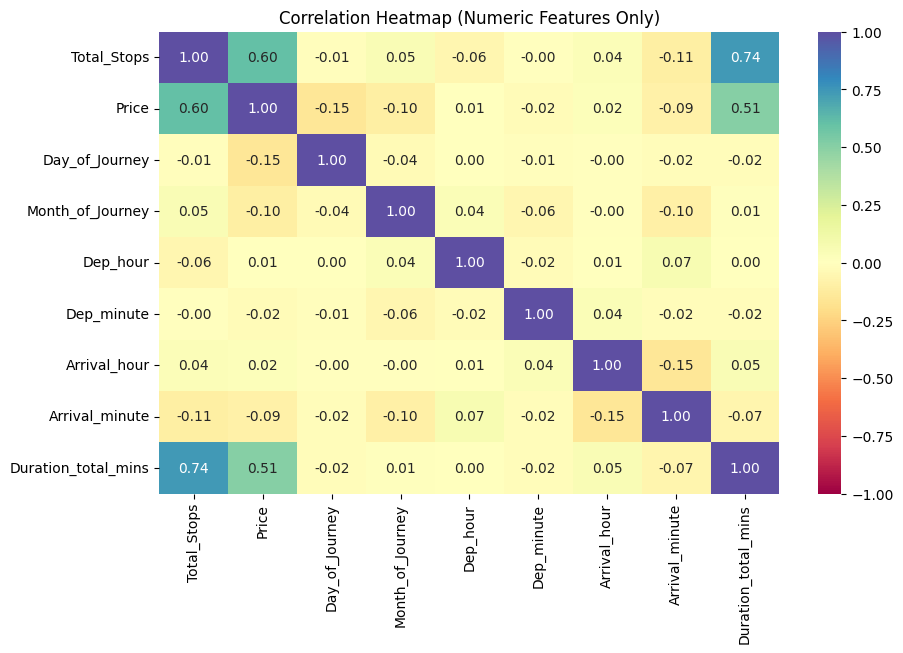

In [32]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    data.select_dtypes(include='number').corr(),
    annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()


***Only `Total_Stops` and `Duration_total_mins` are reasonably correlated with `Price` (Target Variable)***

`Airline` vs `Price`

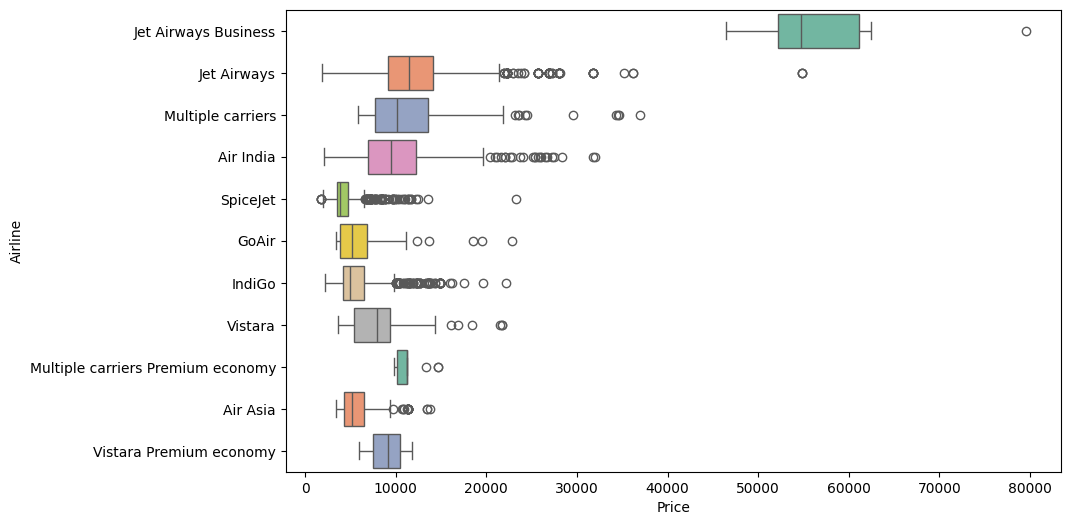

In [33]:
plt.figure(figsize=(10,6))
a=sns.boxplot(x='Price',y='Airline',data=data.sort_values('Price',ascending=False),orient="h", hue='Airline',palette='Set2')

***Jet Airways are charing higher than rest of the Airlines***

`Total Stops` vs `Price`

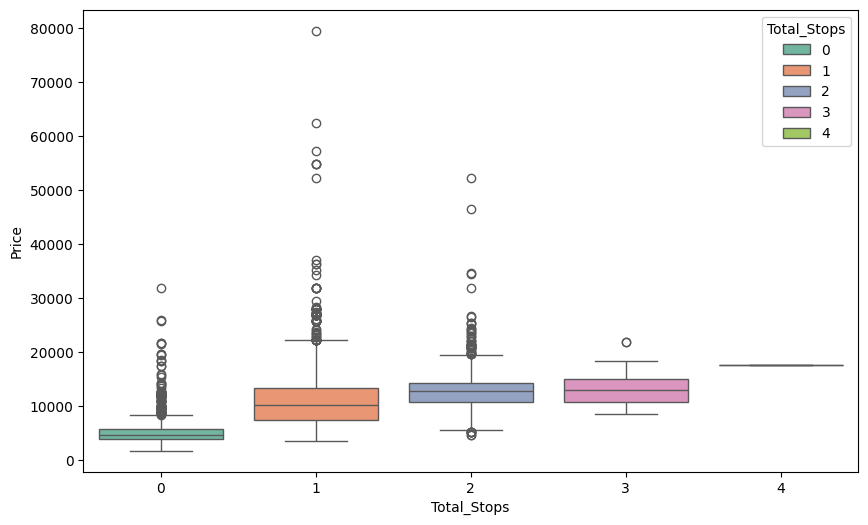

In [34]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Total_Stops',y='Price',data=data.sort_values('Price',ascending=False),hue='Total_Stops',palette='Set2');

***Prices are less for direct flight, gradually increases depending on number of stops***

In [35]:
data.dtypes

Airline                object
Source                 object
Destination            object
Total_Stops             int64
Price                   int64
Day_of_Journey          int32
Month_of_Journey        int32
Dep_hour                int32
Dep_minute              int32
Arrival_hour            int32
Arrival_minute          int32
Duration_total_mins     int64
dtype: object

#### ***Train/Test Split***

In [36]:
##Splitting Independent and dependent variable in X and Y respectively
X = data.drop(['Price'],axis=1)
Y = data[['Price']]

print(X.shape)
print(Y.shape)

(10681, 11)
(10681, 1)


In [37]:
# Splitting the dataset into the Training and Testing set.
X_big, X_test, y_big, y_test = train_test_split(X,Y, test_size = 0.1, random_state = 5,shuffle = True)

In [38]:
# Splitting the dataset into the Training and validation set.
X_train, X_val, y_train, y_val = train_test_split(X_big,y_big, test_size = 0.3, random_state = 5,shuffle = True)

In [39]:
X_train.head()

,Airline,Source,Destination,Total_Stops,Day_of_Journey,Month_of_Journey,Dep_hour,Dep_minute,Arrival_hour,Arrival_minute,Duration_total_mins
6603,Air India,Kolkata,Banglore,1,9,5,20,30,8,55,745
3591,Air India,Kolkata,Banglore,1,1,4,9,50,21,5,675
2831,IndiGo,Banglore,Delhi,0,9,3,5,30,8,20,170
1396,IndiGo,Delhi,Cochin,1,6,4,2,0,7,25,325
2045,Multiple carriers,Delhi,Cochin,1,1,6,14,55,22,30,455


#### ***Normalization***

In [40]:
# Columns to scale
scale_cols = ["Dep_hour", "Dep_minute", "Arrival_hour", "Arrival_minute", "Duration_total_mins"]

# Initialize and fit scaler
sc = StandardScaler()
sc.fit(X_train[scale_cols])

# Transform each dataset
X_train[scale_cols] = sc.transform(X_train[scale_cols])
X_test[scale_cols] = sc.transform(X_test[scale_cols])
X_val[scale_cols] = sc.transform(X_val[scale_cols])


Since we are solving the regression module, we will scale the target variable. One of the reasons to scale the data is to reduce the time complexity for updating the weights during the backpropagation, which uses the derivatives. 

For classification problem, there is no need of scaling the target variable.

In [41]:
# Scaling the Target variable (contionous variable) 
y_train = sc.fit_transform(y_train)  
y_val_scale = sc.transform(y_val)

***Categorical Encoding***

In [42]:
## Storing required categorical variables in cat_data to apply dummification 
cat_data = ["Airline",'Source','Destination']

# Using pd.get dummies to encode the categorical columns in the data
X_train = pd.get_dummies(X_train,columns=cat_data,drop_first= True)
X_test = pd.get_dummies(X_test,columns=cat_data,drop_first= True)
X_val = pd.get_dummies(X_val,columns=cat_data,drop_first= True)   

In [43]:
# Checking the shape
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)
print(X_val.columns)

(6728, 26)
(2884, 25)
(6728, 1)
(2884, 1)
(1069, 24)
(1069, 1)
Index(['Total_Stops', 'Day_of_Journey', 'Month_of_Journey', 'Dep_hour',
       'Dep_minute', 'Arrival_hour', 'Arrival_minute', 'Duration_total_mins',
       'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Vistara', 'Source_Chennai', 'Source_Delhi', 'Source_Kolkata',
       'Source_Mumbai', 'Destination_Cochin', 'Destination_Delhi',
       'Destination_Hyderabad', 'Destination_Kolkata'],
      dtype='object')


***We will use `DataFrame.align()` to ensure that X_train, X_test, and X_val all have the same columns in the same order***

In [44]:
X_train,X_test = X_train.align(X_test,join='outer',axis=1,fill_value=0) #  fill_value=0 will fill the missing columns with 0's
X_train,X_val = X_train.align(X_val,join='outer',axis=1,fill_value=0)

In [45]:
# Checking the shape
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)
print(X_val.columns)

(6728, 26)
(2884, 26)
(6728, 1)
(2884, 1)
(1069, 26)
(1069, 1)
Index(['Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Vistara', 'Airline_Vistara Premium economy', 'Arrival_hour',
       'Arrival_minute', 'Day_of_Journey', 'Dep_hour', 'Dep_minute',
       'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Duration_total_mins', 'Month_of_Journey',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Total_Stops'],
      dtype='object')


#### ***Performance Evaluation***

- *We will be using metric functions defined in sklearn for RMSE, MAE, and $R^2$.*

#### ***Model Building***

- We will now start with the model building process.
- We will create a model.
 - Three hidden layer with ReLU as activation function.
 - Output layer with 1 nodes (For regression problem )

***`Model-1`***

In [46]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

- *`activation='relu'` Applies the Rectified Linear Unit function, outputting zero for negatives and identity for positives to introduce non-linearity and avoid vanishing gradients.*
- *`activation='linear'` Outputs the input as-is, making it suitable for regression tasks where the output can take any continuous value.*
- *`kernel_initializer='he_uniform'` Initializes weights from a uniform distribution scaled for ReLU activations, helping deep networks converge faster and more stably.*

In [47]:
# Initializing the model
model = Sequential()
# Adding input layer with 64 neurons, relu as activation function and, he_uniform as weight initializer.
model.add(Dense(64, activation='relu',kernel_initializer='he_uniform', input_shape=(26,)))
# Adding the first hidden layer with 32 neurons, relu as activation function and, he_uniform as weight initializer
model.add(Dense(32, activation='relu',kernel_initializer='he_uniform'))
# Adding the second hidden layer with 32 neurons, relu as activation function and, he_uniform as weight initializer
model.add(Dense(32, activation='relu',kernel_initializer='he_uniform'))
# Adding the output layer with one neuron and linear as activation
model.add(Dense(1, activation='linear'))

In [48]:
# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

- *`optimizer = RMSprop()` Uses a moving average of squared gradients to adapt learning rates, ideal for noisy or non-stationary objectives.*
- *`loss='mse'` Measures the average squared difference between predicted and actual values, penalizing larger errors more heavily.*
- *`metrics = ['mae']` Tracks the mean absolute error during training, offering a more interpretable measure of average prediction deviation.*

In [49]:
# Initializing the Optimizer
optimizer = RMSprop( learning_rate=0.001)
# Compiling the model with 'mse' as loss function and metrics
model.compile(loss='mse',
              optimizer=optimizer,
              metrics=['mae'])
# Fitting the model on train and validation with 50 epochs
history = model.fit(X_train, y_train, validation_data=(X_val, y_val_scale), epochs=50)

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 938us/step - loss: 0.6242 - mae: 0.5397 - val_loss: 0.4090 - val_mae: 0.4413
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - loss: 0.4495 - mae: 0.4560 - val_loss: 0.3836 - val_mae: 0.4311
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 538us/step - loss: 0.4061 - mae: 0.4346 - val_loss: 0.3615 - val_mae: 0.4244
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 536us/step - loss: 0.3753 - mae: 0.4194 - val_loss: 0.3358 - val_mae: 0.4087
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step - loss: 0.3535 - mae: 0.4080 - val_loss: 0.3283 - val_mae: 0.4043
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step - loss: 0.3368 - mae: 0.3990 - val_loss: 0.3205 - val_mae: 0.4006
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 529us/step - loss: 0.3232 - mae: 0.3922 - val_loss: 0.3163 - val_mae: 0.3971
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - loss: 0.3116 - mae: 0.3861 - val_loss: 0.3084 - val_mae: 0.3915
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 

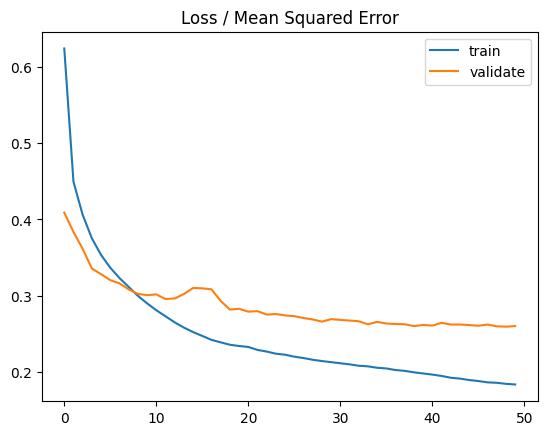

In [50]:
plt.title('Loss / Mean Squared Error')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validate')
plt.legend()
plt.show()

*Here the model seems to be overfitted, as the distance between the train curve and validation curve started diverging*

In [51]:
#Lets predict on validation data
Y_result_scaled= model.predict(X_val)
##As we have scaled the target variable, now after predicting we should inverse the scale and convert it to normal form
Y_result = sc.inverse_transform(Y_result_scaled) 

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 456us/step


In [52]:
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

def model_performance_regression(predictors,target,pred):
  r2 = r2_score(target, pred)  # to compute R-squared
  adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
  rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
  mae = mean_absolute_error(target, pred)  # to compute MAE

  df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
        },
        index=[0],
    )

  return df_perf

In [53]:
# Checking model performance on train set
print("Validation Performance\n")
model_train_perf = model_performance_regression(X_val,y_val, Y_result)
model_train_perf

Validation Performance



,RMSE,MAE,R-squared,Adj. R-squared
0,2344.483738,1633.288086,0.731277,0.728831


* Now, let's try using Early stopping and see if we can overcome the overfitting problem, we can also change the optimizer and use Adam.  

***`Model-2` Early Stopping***

***Early stopping:*** 

*During training, the model is evaluated on a holdout validation dataset after each epoch. If the performance of the model on the validation dataset starts to degrade or no improvement (e.g. loss begins to increase or accuracy begins to decrease), then the training process is stopped after the certian interations.The model at the time that training is stopped is then used and is known to have good generalization performance.*

*This procedure is called “early stopping” and is perhaps one of the oldest and most widely used forms of neural network regularization.*

In [54]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

In [55]:
# Initializing the model
model_2 = Sequential()
# Adding input layer with 64 neurons, relu as activation function and, he_uniform as weight initializer.
model_2.add(Dense(64, activation='relu',kernel_initializer='he_uniform', input_shape=(26,)))
# Adding the first hidden layer with 32 neurons, relu as activation function and, he_uniform as weight initializer
model_2.add(Dense(32, activation='relu',kernel_initializer='he_uniform'))
# Adding the second hidden layer with 32 neurons, relu as activation function and, he_uniform as weight initializer
model_2.add(Dense(32, activation='relu',kernel_initializer='he_uniform'))
# Adding the output layer with one neuron and linear as activation
model_2.add(Dense(1, activation='linear'))

In [56]:
# Model summary
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

- *`optimier = Adam()` Combines the benefits of AdaGrad and RMSprop by adaptively adjusting learning rates using first and second moment estimates of gradients, making it highly effective for deep learning tasks.*

In [57]:
# Initializing the Optimizer
optimizer = Adam( learning_rate=0.001)
# Compiling the model with 'mse' as loss function and metrics
model_2.compile(loss='mse',
              optimizer=optimizer,
              metrics=['mae'])
# Defining Early stopping
es_cb = callbacks.EarlyStopping(monitor='val_loss', min_delta=0.001, patience=5)
# Fitting the model on train and validation with 50 epochs
history_2 = model_2.fit(X_train, y_train, validation_data=(X_val, y_val_scale), epochs=50,callbacks=es_cb)

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.7002 - mae: 0.5663 - val_loss: 0.4076 - val_mae: 0.4439
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step - loss: 0.4164 - mae: 0.4338 - val_loss: 0.3560 - val_mae: 0.4264
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step - loss: 0.3755 - mae: 0.4216 - val_loss: 0.3397 - val_mae: 0.4298
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step - loss: 0.3503 - mae: 0.4139 - val_loss: 0.3376 - val_mae: 0.4338
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 611us/step - loss: 0.3292 - mae: 0.4065 - val_loss: 0.3170 - val_mae: 0.4230
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 542us/step - loss: 0.3084 - mae: 0.3972 - val_loss: 0.3070 - val_mae: 0.4147
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step - loss: 0.2915 - mae: 0.3910 - val_loss: 0.3004 - val_mae: 0.4112
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - loss: 0.2771 - mae: 0.3838 - val_loss: 0.2945 - val_mae: 0.4045
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s

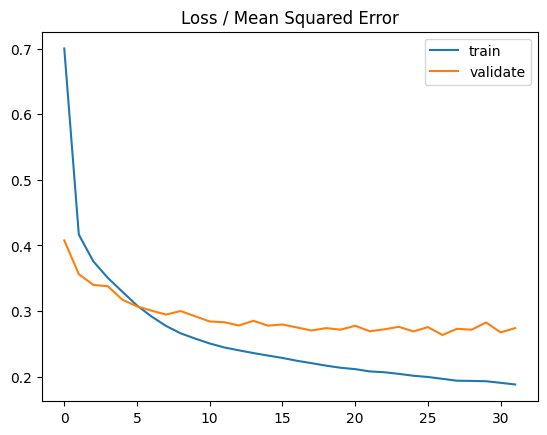

In [58]:
plt.title('Loss / Mean Squared Error')
plt.plot(history_2.history['loss'], label='train')
plt.plot(history_2.history['val_loss'], label='validate')
plt.legend()
plt.show()

***The train and validation curves are smooth after using Adam, although they appear to be slightly overfitted.*** 

In [59]:
#Lets predict on validation data
Y_result_scaled_2= model_2.predict(X_val)
##As we have scaled the target variable, now after predicting we should inverse the scale and should convert to normal form
Y_result2 = sc.inverse_transform(Y_result_scaled_2) 

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step


In [60]:
# Checking model performance on train set
print("Validation Performance\n")
model_train_perf = model_performance_regression(X_val,y_val, Y_result2)
model_train_perf

Validation Performance



,RMSE,MAE,R-squared,Adj. R-squared
0,2404.495893,1741.77832,0.717343,0.714771


Changing the optimizer didn't work, and even the Adj R-square has decreased when compared to previous model. 

* Let's use two Regularization techniques to reduce the overfitting problem. 

 - Dropout 
 - BatchNormalization

***`Model-3` - Using Dropout***

***Dropout***

*Dropout is a technique where randomly selected neurons are ignored during training. They are “dropped-out” randomly.*

In [61]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

In [62]:
# Initializing the model
model_3 = Sequential()
# Adding input layer with 64 neurons, relu as activation function and, he_uniform as weight initializer.
model_3.add(Dense(64, activation='relu',kernel_initializer='he_uniform', input_shape=(26,)))
# Adding Dropout with 20%
model_3.add(Dropout(0.2))
# Adding the first hidden layer with 32 neurons, relu as activation function and, he_uniform as weight initializer
model_3.add(Dense(32, activation='relu',kernel_initializer='he_uniform'))
# Adding Dropout with 10%
model_3.add(Dropout(0.2))
# Adding the second hidden layer with 32 neurons, relu as activation function and, he_uniform as weight initializer
model_3.add(Dense(16, activation='relu',kernel_initializer='he_uniform'))
# Adding the output layer with one neuron and linear as activation
model_3.add(Dense(1, activation='linear'))

In [63]:
# Model summary
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# Initializing the Optimizer
optimizer = Adam(0.001)
# Compiling the model with 'mse' as loss function and metrics
model_3.compile(loss='mse',
              optimizer=optimizer,
              metrics=['mae'])
# Defining Early stopping
es_cb = callbacks.EarlyStopping(monitor='val_loss', min_delta=0.001, patience=5)
# Fitting the model on train and validation with 50 epochs
history_3 = model_3.fit(X_train, y_train, validation_data=(X_val, y_val_scale), epochs=50,callbacks=es_cb)

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 990us/step - loss: 1.9461 - mae: 1.0320 - val_loss: 0.9069 - val_mae: 0.7618
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step - loss: 0.9923 - mae: 0.7585 - val_loss: 0.7671 - val_mae: 0.6902
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step - loss: 0.8126 - mae: 0.6650 - val_loss: 0.5911 - val_mae: 0.5803
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step - loss: 0.7074 - mae: 0.6085 - val_loss: 0.5335 - val_mae: 0.5507
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step - loss: 0.6380 - mae: 0.5735 - val_loss: 0.5043 - val_mae: 0.5465
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step - loss: 0.5784 - mae: 0.5438 - val_loss: 0.4431 - val_mae: 0.5065
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 579us/step - loss: 0.5426 - mae: 0.5211 - val_loss: 0.4159 - val_mae: 0.4892
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step - loss: 0.4989 - mae: 0.5060 - val_loss: 0.3884 - val_mae: 0.4839
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 

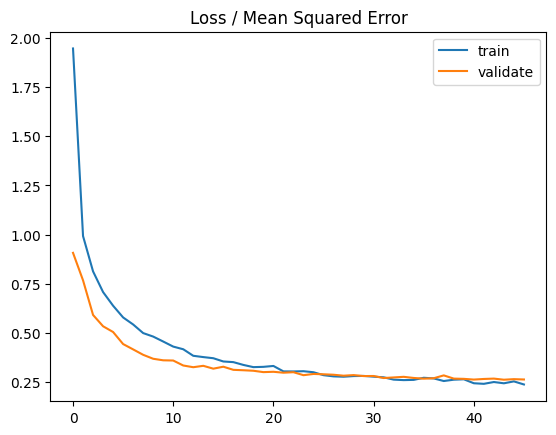

In [65]:
plt.title('Loss / Mean Squared Error')
plt.plot(history_3.history['loss'], label='train')
plt.plot(history_3.history['val_loss'], label='validate')
plt.legend()
plt.show()

***After using Dropout technique the train and validation curves seems to be smooth.***

In [66]:
Y_result_scaled_3= model_3.predict(X_val)
Y_result_3 = sc.inverse_transform(Y_result_scaled_3)

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step


In [67]:
# Checking model performance on train set
print("Validation Performance\n")
model_train_perf = model_performance_regression(X_val,y_val, Y_result_3)
model_train_perf

Validation Performance



,RMSE,MAE,R-squared,Adj. R-squared
0,2356.608686,1799.537109,0.72849,0.726019


***`Model-4` Using Batch Normalization***

In [68]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

In [69]:
# Initializing the model
model_4 = Sequential()
# Adding input layer with 64 neurons, relu as activation function and, he_uniform as weight initializer.
model_4.add(Dense(64, activation='relu',kernel_initializer='he_uniform', input_shape=(26,)))
# Adding the first hidden layer with 32 neurons, relu as activation function and, he_uniform as weight initializer
model_4.add(Dense(32, activation='relu',kernel_initializer='he_uniform'))
# Adding Batch Normalization
model_4.add(BatchNormalization())
# Adding the second hidden layer with 32 neurons, relu as activation function and, he_uniform as weight initializer
model_4.add(Dense(32, activation='relu',kernel_initializer='he_uniform'))
# Adding the output layer with one neuron and linear as activation
model_4.add(Dense(1, activation='linear'))

In [70]:
# Model summary
model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,025 (19.63 KB)

 Trainable params: 4,961 (19.38 KB)

 Non-trainable params: 64 (256.00 B)

In [71]:
# Initializing the Optimizer
optimizer = Adam(0.001)
# Compiling the model with 'mse' as loss function and metrics
model_4.compile(loss='mse',
              optimizer=optimizer,
              metrics=['mae'])
# Defining Early stopping
es_cb = callbacks.EarlyStopping(monitor='val_loss', min_delta=0.001, patience=5)
# Fitting the model on train and validation with 50 epochs
history_4 = model_4.fit(X_train, y_train, validation_data=(X_val, y_val_scale), epochs=50,callbacks=es_cb)

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.6641 - mae: 0.5686 - val_loss: 0.4893 - val_mae: 0.5199
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 579us/step - loss: 0.4504 - mae: 0.4680 - val_loss: 0.3856 - val_mae: 0.4494
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - loss: 0.3971 - mae: 0.4412 - val_loss: 0.3583 - val_mae: 0.4276
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step - loss: 0.3633 - mae: 0.4254 - val_loss: 0.3240 - val_mae: 0.4179
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step - loss: 0.3366 - mae: 0.4114 - val_loss: 0.3163 - val_mae: 0.4033
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - loss: 0.3166 - mae: 0.4030 - val_loss: 0.3376 - val_mae: 0.4091
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 579us/step - loss: 0.3078 - mae: 0.3989 - val_loss: 0.3199 - val_mae: 0.4168
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 675us/step - loss: 0.2922 - mae: 0.3924 - val_loss: 0.3117 - val_mae: 0.3924
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s

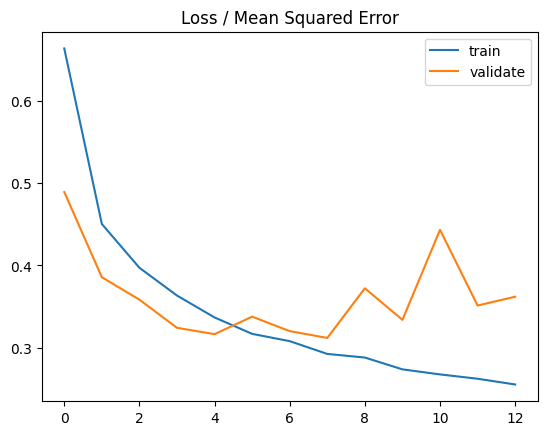

In [72]:
plt.title('Loss / Mean Squared Error')
plt.plot(history_4.history['loss'], label='train')
plt.plot(history_4.history['val_loss'], label='validate')
plt.legend()
plt.show()

In [73]:
Y_result_scaled_4= model_4.predict(X_val)
Y_result_4 = sc.inverse_transform(Y_result_scaled_4)

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step


In [74]:
# Checking model performance on train set
print("Validation Performance\n")
model_train_perf = model_performance_regression(X_val,y_val, Y_result_4)
model_train_perf

Validation Performance



,RMSE,MAE,R-squared,Adj. R-squared
0,2764.342236,1754.025024,0.626411,0.623011


* BatchNormalization technique did not perform well on and even the Adjusted R-square dropped sharply.
* Let's try to build another model using Dropout with different neural network architecture and see if we can improve the Adjusted R-square. 

***`Model-5` Using Dropout and Other changes***

In [75]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(42)
import random
random.seed(42)
tf.random.set_seed(42)

In [76]:
# Initializing the model
model_5 = Sequential()
# Adding input layer with 64 neurons, relu as activation function and, he_uniform as weight initializer.
model_5.add(Dense(64, activation='relu',kernel_initializer='he_uniform', input_shape=(26,)))
# Adding dropout with ratio of 0.1
model_5.add(Dropout(0.2))
# Adding the first hidden layer with 32 neurons, relu as activation function and, he_uniform as weight initializer
model_5.add(Dense(32, activation='relu',kernel_initializer='he_uniform'))
# Adding dropout with ratio of 0.1
model_5.add(Dropout(0.1))
# Adding the second hidden layer with 16 neurons, relu as activation function and, he_uniform as weight initializer
model_5.add(Dense(16, activation='relu',kernel_initializer='he_uniform'))
# Adding the third hidden layer with 8 neurons, relu as activation function and, he_uniform as weight initializer
model_5.add(Dense(8, activation='relu',kernel_initializer='he_uniform'))
# Adding the output layer with one neuron and linear as activation
model_5.add(Dense(1, activation='linear'))

In [77]:
# Model summary
model_5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,481 (17.50 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
# Initializing the Optimizer
optimizer = Adam(0.001)
# Compiling the model with 'mse' as loss function and metrics
model_5.compile(loss='mse',
              optimizer=optimizer,
              metrics=['mae'])
# Adding the callbacks
es_cb = callbacks.EarlyStopping(monitor='val_loss', min_delta=0.001, patience=5)
# Fitting the model on train and validation with 50 epochs
history_5 = model_5.fit(X_train, y_train, validation_data=(X_val, y_val_scale), epochs=50,callbacks=es_cb)

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.7577 - mae: 0.9804 - val_loss: 0.8944 - val_mae: 0.7487
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step - loss: 1.0298 - mae: 0.7759 - val_loss: 0.7744 - val_mae: 0.6879
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step - loss: 0.8386 - mae: 0.6839 - val_loss: 0.5942 - val_mae: 0.5808
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 633us/step - loss: 0.7141 - mae: 0.6102 - val_loss: 0.5025 - val_mae: 0.5278
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 614us/step - loss: 0.6354 - mae: 0.5740 - val_loss: 0.4499 - val_mae: 0.5068
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step - loss: 0.5678 - mae: 0.5354 - val_loss: 0.4036 - val_mae: 0.4778
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - loss: 0.5063 - mae: 0.5026 - val_loss: 0.3713 - val_mae: 0.4562
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 758us/step - loss: 0.4848 - mae: 0.4887 - val_loss: 0.3622 - val_mae: 0.4619
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s

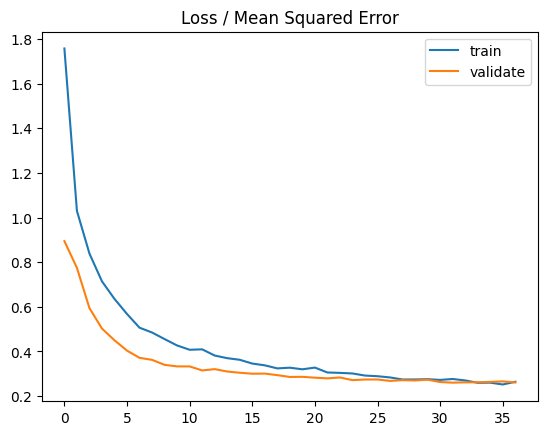

In [79]:
plt.title('Loss / Mean Squared Error')
plt.plot(history_5.history['loss'], label='train')
plt.plot(history_5.history['val_loss'], label='validate')
plt.legend()
plt.show()

* We can observe that after increasing the layers, both the curves seems to be smooth. 

In [80]:
Y_result_scaled_5= model_5.predict(X_val)
Y_result_5 = sc.inverse_transform(Y_result_scaled_5)

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step


In [81]:
# Checking model performance on train set
print("Validation Performance\n")
model_train_perf = model_performance_regression(X_val,y_val, Y_result_5)
model_train_perf

Validation Performance



,RMSE,MAE,R-squared,Adj. R-squared
0,2346.913612,1746.758667,0.730719,0.728269


The Adjusted R-square of the model increased, and increasing the number of layers did work to improve the metrics.

Out of all the models built, the final Model-5 with the dropout technique gives a good Adjusted R-Square when compared to all the models. Now let's predict on the test data using Model-5. 

***Test Prediction***

In [82]:
# Predicting on test dat
test_pred = model_5.predict(X_test)
##As we have scaled the target variable, now after predicting we should inverse the scale and should convert to normal form
test_pred = sc.inverse_transform(test_pred)
print(test_pred)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 413us/step
[[12138.307]
 [ 6040.458]
 [11309.702]
 ...
 [11516.652]
 [ 9202.466]
 [11373.259]]


In [83]:
# Checking model performance on train set
print("Training Performance\n")
model_train_perf = model_performance_regression(X_test,y_test, test_pred)
model_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared
0,2743.054775,1797.574097,0.690603,0.682883


- We have trained 5 different models with some changes in architecture and Optimizer.
- Just by increasing one layer in the last model, we were able to reduce the loss.
- Someday, I will take this code and do more experiments - NK